This code preprocesses and merges the sample, patient and gene expression data into a single dataset.<br>

In [100]:
import pandas as pd
import numpy as np

Load sample and patient data from TCGA GDC dataset

In [ ]:
clinical_sample = pd.read_csv("../dataset/skcm_tcga_gdc/data_clinical_sample.txt", sep='\t', comment='#')
clinical_patient = pd.read_csv("../dataset/skcm_tcga_gdc/data_clinical_patient.txt", sep='\t', comment='#')

Remove redundant features

In [ ]:
sample_drop_cols = [
    "OTHER_SAMPLE_ID",        # identifier, not a feature
    "IS_FFPE",                # constant: all "NO"
    "ONCOTREE_CODE",          # constant: all "SKCM"
    "CANCER_TYPE",            # constant: all "Cutaneous Melanoma"
    "CANCER_TYPE_DETAILED",   # constant: all "Cutaneous Melanoma"
    "SAMPLE_TYPE_ID",         # redundant numeric duplicate of SAMPLE_TYPE
]

patient_drop_cols = [
    "DAYS_TO_DEATH",        # leakage: derives OS_MONTHS/OS_STATUS
    "DAYS_LAST_FOLLOWUP",   # leakage: same reason
    "DAYS_TO_BIRTH",        # redundant, = -AGE*365
    "VITAL_STATUS",         # redundant/duplicate of OS_STATUS
    "AJCC_STAGING_EDITION", # non-prognostic administrative field
    "BIOPSY_SITE",          # duplicate of PRIMARY_SITE_PATIENT (confirmed identical)
    "DFS_STATUS",           # 94% missing + wrong endpoint (see OS/DFS discussion)
    "DFS_MONTHS",           # same
    "OTHER_PATIENT_ID",     # identifier, not a feature
    "PROJECT_ID",           # constant: all "TCGA-SKCM"
    "PROJECT_NAME",         # constant: all "Cutaneous Melanoma"
    "PROJECT_STATE",        # constant: all "released"
]

clinical_sample = clinical_sample.drop(columns=sample_drop_cols)
clinical_patient = clinical_patient.drop(columns=patient_drop_cols)

Load and preprocess gene expression data

In [111]:
gex = pd.read_csv("../dataset/skcm_tcga_gdc/data_mrna_seq_tpm.txt", sep='\t', comment='#')

# find gene symbol (HGNC) through mapping
gene_map = pd.read_csv("../dataset/skcm_tcga_gdc/ensembl_biomart_canonical_transcripts_per_hgnc.txt", sep='\t', usecols=["hgnc_symbol", "entrez_gene_id"])
gex = gex.rename(columns={"Entrez_Gene_Id": "entrez_gene_id"})
gene_map = gene_map.dropna(subset=["entrez_gene_id"])
gene_map["entrez_gene_id"] = gene_map["entrez_gene_id"].astype(int)
gex = gex.merge(gene_map, on="entrez_gene_id", how="left")
gex = gex.drop(columns=['entrez_gene_id'])

# transform to rows of sampleids
gex = gex.set_index('hgnc_symbol').T
gex.index.name = 'SAMPLE_ID'
gex = gex.reset_index()

Merge all 3 datasets

In [ ]:
clinical_gex = pd.merge(gex, clinical_sample, on='SAMPLE_ID', how='inner')
clinical_gex = pd.merge(clinical_gex, clinical_patient, on='PATIENT_ID', how='inner')
clinical_gex

Plot Kaplan-Meier OS Curve to decide OS threshold

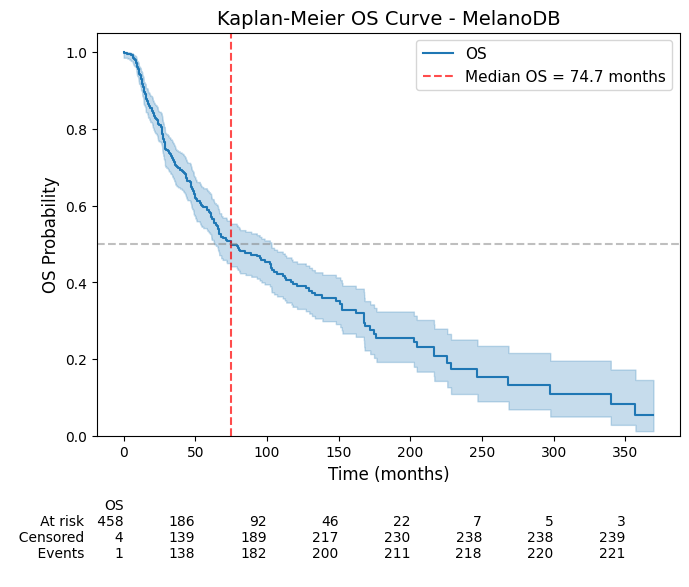

Median OS: 74.7 months
Total patients: 463
Events (deaths): 222
Censored: 241


In [114]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

df = clinical_gex.dropna(subset=['OS_MONTHS', 'OS_STATUS']).copy()
df['OS_EVENT'] = (df['OS_STATUS'] == '1:DECEASED').astype(int)

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df['OS_MONTHS'],
    event_observed=df['OS_EVENT'],  # 1 = death, 0 = censored
    label='OS'
)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,          # show 95% confidence interval
    at_risk_counts=True,   # show number at risk below plot
)

# Add median line
median_pfs = kmf.median_survival_time_
ax.axvline(x=median_pfs, color='red', linestyle='--', alpha=0.7, label=f'Median OS = {median_pfs:.1f} months')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('OS Probability', fontsize=12)
ax.set_title('Kaplan-Meier OS Curve - MelanoDB', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('km_curve.png', dpi=150)
plt.show()

print(f'Median OS: {median_pfs:.1f} months')
print(f'Total patients: {len(df)}')
print(f'Events (deaths): {int(df["OS_EVENT"].sum())}')
print(f'Censored: {int((df["OS_EVENT"] == 0).sum())}')

Define target base on OS month and OS status

In [115]:
LONG_RESP_THRESHOLD = 175
SHORT_RESP_THRESHOLD = 74.7

def label_os(row):
    # if row['OS_MONTHS'] >= LONG_RESP_THRESHOLD:
    if row['OS_MONTHS'] >= SHORT_RESP_THRESHOLD:
        return 1
    elif row['OS_MONTHS'] < SHORT_RESP_THRESHOLD and row['OS_STATUS'] == '1:DECEASED':
        return 0
    return np.nan

clinical_gex['os_label'] = clinical_gex.apply(label_os, axis=1)
clinical_gex = clinical_gex.drop(columns=['OS_MONTHS', 'OS_STATUS']).dropna(subset=['os_label'])
clinical_gex['os_label'] = clinical_gex['os_label'].astype(int)

In [116]:
clinical_gex.to_csv('../dataset/created/tcga_gdc.csv', index=False)